# Ejercicio 1

Dado el conjunto de puntos que puede descargar del [siguiente enlace](https://drive.google.com/file/d/1g8KNOJsaE3jzXob-ZsTE_PqYwuxJ05pg/export?format=txt), genere un modelo de regresión multicapa que permita aproximar la tendencia del dataset.

![DiagramaElectrico](https://drive.google.com/uc?export=view&id=1a3zJAPE3DQi06LktoVoBlb91eaMHYkvv)

# Ejercicio 2

Existe una base de datos llamada MNIST que contiene imágenes de dígitos manuscritos:

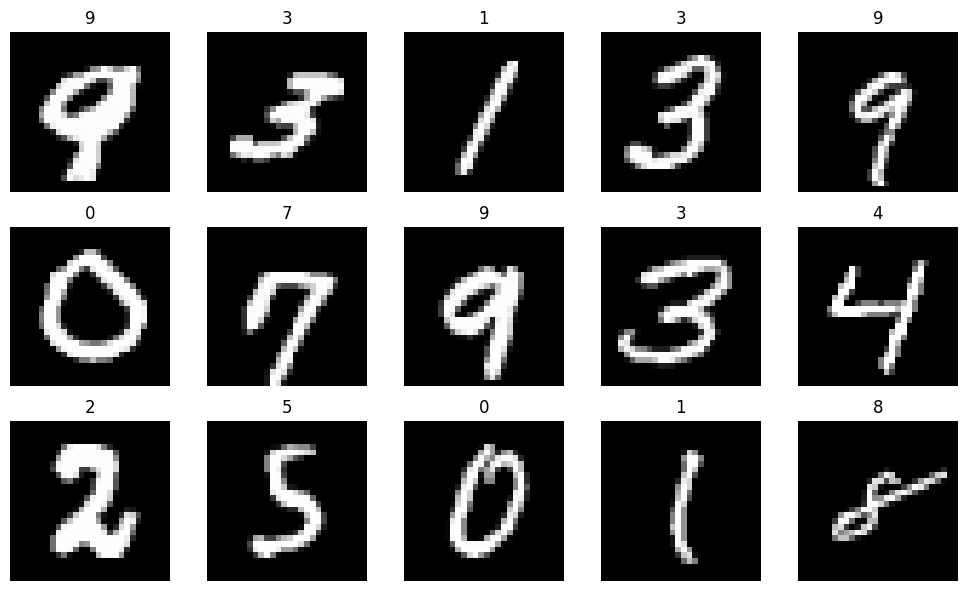

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist

# Cargar el dataset MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Mostrar 15 ejemplos aleatorios
r, c = 3, 5
fig = plt.figure(figsize=(2*c, 2*r))
for _r in range(r):
    for _c in range(c):
        ix = np.random.randint(0, len(X_train))
        img = X_train[ix]
        plt.subplot(r, c, _r*c + _c + 1)
        plt.imshow(img, cmap='gray')
        plt.axis("off")
        plt.title(y_train[ix])
plt.tight_layout()
plt.show()


In [3]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

n_train_samples = X_train.shape[0]
n_test_samples = X_test.shape[0]
n_features = 10

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"Nuumero de ejemplos de entrenamiento: {n_train_samples}")
print(f"Numero de ejemplos de prueba: {n_test_samples}")
print(f"Un ejemplo de las primeras 5 variables de salida:\r\n{y_train[:5]} en formato {type(y_train)} y tipo de dato {type(y_train[0])}")

X_train shape: (60000, 28, 28)
y_train shape: (60000,)
Nuumero de ejemplos de entrenamiento: 60000
Numero de ejemplos de prueba: 10000
Un ejemplo de las primeras 5 variables de salida:
[5 0 4 1 9] en formato <class 'numpy.ndarray'> y tipo de dato <class 'numpy.uint8'>


Normalice las imágenes del dataset y utilice la librería `scikitlearn` para crear un modelo que permita clasificar el dataset correctamente para indicar el valor representado en cada imagen.

In [ ]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Aplanamiento (Flattening)
X_train_flat = X_train.reshape(X_train.shape[0], -1) 
X_test_flat = X_test.reshape(X_test.shape[0], -1)
print(f"Dimensiones de X_train_flat: {X_train_flat.shape}")

# Normalizacion
scaler = MinMaxScaler()
X_train_normalized = scaler.fit_transform(X_train_flat)
X_test_normalized = scaler.transform(X_test_flat)

# Instanciamos el modelo con los hiperparámetros deseados
rf_model = RandomForestClassifier(
    n_estimators=150,       # Cantidad de árboles (ej: 150)
    max_depth=20,           # Profundidad máxima para evitar sobreajuste
    random_state=42,        # Semilla aleatoria para que tus resultados sean reproducibles
    n_jobs=-1               # Utilizar todos los núcleos del procesador
)

# Entrenamiento
print("Entrenando el modelo Random Forest...")
rf_model.fit(X_train_normalized, y_train)
print("¡Entrenamiento completado!")

# Prediccion vectorizada en subconjunto de validacion
y_pred = rf_model.predict(X_test_normalized)

# suma de aciertos/totales
exactitud = accuracy_score(y_test, y_pred)

print(f"Exactitud (Accuracy) del modelo: {exactitud * 100:.2f}%")

Dimensiones de X_train_flat: (60000, 784)
Entrenando el modelo Random Forest...
¡Entrenamiento completado!
Total de muestras de prueba: 10000
Exactitud (Accuracy) del modelo: 96.86%


In [14]:
from sklearn.model_selection import GridSearchCV

# 1. Definimos el modelo base (fijamos n_estimators bajo para la búsqueda)
rf_base = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)

# 2. Definimos la cuadrícula de valores a barrer (tu rango de 10 a 50)
param_grid = {
    'max_depth': [10, 15, 20, 25, 30, 35, 40, 45, 50]
}

# 3. Configuramos la búsqueda con Validación Cruzada (cv=5 significa 5 pliegues)
grid_search = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid,
    cv=5, 
    scoring='accuracy',
    verbose=2 # Para ver el progreso en consola
)

# 4. Ejecutamos la búsqueda SOLO con los datos de entrenamiento
print("Iniciando barrido de hiperparámetros...")
grid_search.fit(X_train_normalized, y_train)

# 5. Extraemos el mejor resultado
print(f"El mejor max_depth encontrado es: {grid_search.best_params_['max_depth']}")

Iniciando barrido de hiperparámetros...
Fitting 5 folds for each of 9 candidates, totalling 45 fits
[CV] END .......................................max_depth=10; total time=   5.0s
[CV] END .......................................max_depth=10; total time=   4.5s
[CV] END .......................................max_depth=10; total time=   4.8s
[CV] END .......................................max_depth=10; total time=   4.9s
[CV] END .......................................max_depth=10; total time=   4.8s
[CV] END .......................................max_depth=15; total time=   6.2s
[CV] END .......................................max_depth=15; total time=   6.5s
[CV] END .......................................max_depth=15; total time=   6.1s
[CV] END .......................................max_depth=15; total time=   6.3s
[CV] END .......................................max_depth=15; total time=   6.1s
[CV] END .......................................max_depth=20; total time=   6.6s
[CV] END 

In [15]:
# Instanciamos el modelo con max_depth optimizado y un mayor numero de árboles
rf_model = RandomForestClassifier(
    n_estimators=500,
    max_depth=25,
    random_state=42,
    n_jobs=-1
)

# Entrenamiento
print("Entrenando el modelo Random Forest...")
rf_model.fit(X_train_normalized, y_train)
print("¡Entrenamiento completado!")

# Prediccion vectorizada en subconjunto de validacion
y_pred = rf_model.predict(X_test_normalized)

# suma de aciertos/totales
exactitud = accuracy_score(y_test, y_pred)

print(f"Exactitud (Accuracy) del modelo: {exactitud * 100:.2f}%")

Entrenando el modelo Random Forest...
¡Entrenamiento completado!
Exactitud (Accuracy) del modelo: 97.15%


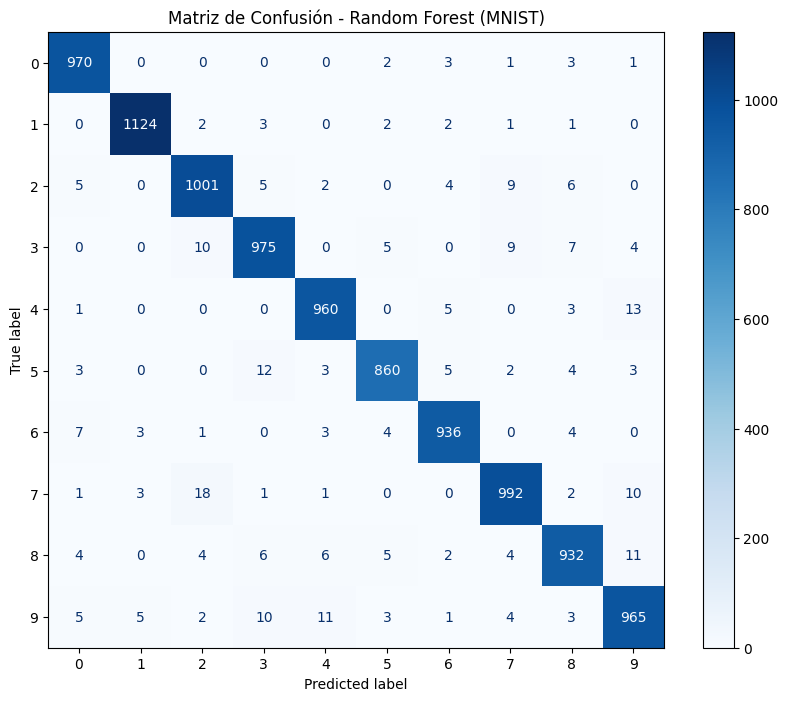

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# 1. Generamos las predicciones vectorizadas (si no lo habías hecho en el paso anterior)
y_pred = rf_model.predict(X_test_normalized)

# 2. Configuramos el tamaño del lienzo de la figura
fig, ax = plt.subplots(figsize=(10, 8))

# 3. Scikit-learn calcula la matriz y la dibuja automáticamente
ConfusionMatrixDisplay.from_predictions(
    y_true=y_test, 
    y_pred=y_pred,
    cmap='Blues',
    ax=ax,             # Le indicamos que dibuje sobre el lienzo que creamos
    values_format='d'  # Formato entero
)

# 4. Agregamos un título y mostramos
plt.title("Matriz de Confusión - Random Forest (MNIST)")
plt.show()

In [ ]:
import tkinter as tk
from tkinter import ttk
from PIL import Image, ImageOps
import numpy as np

# --- NOTA: Se debe importar el modelo entrenado aquí ---
# Supongamos que lo tienes en la variable 'rf_model' de tus pasos anteriores
# Si no lo tienes entrenado en esta sesión, debes cargarlo.
# import joblib
# rf_model = joblib.load('tu_modelo_mnist_entrenado.pkl')
# --- ------------------------------------------------ ---

class MNISTApp:
    def __init__(self, root, trained_model, canvas_size=280):
        self.root = root
        self.rf_model = trained_model
        self.canvas_size = canvas_size
        
        self.root.title("Clasificador Interactivo de Dígitos")
        
        # 1. Lienzo para dibujar
        self.canvas = tk.Canvas(root, width=canvas_size, height=canvas_size, bg="white", cursor="cross")
        self.canvas.grid(row=0, column=0, padx=10, pady=10)
        
        # 2. Lienzo off-screen optimizado
        self.image = Image.new("L", (canvas_size, canvas_size), "white")
        
        # IMPORTANTE: Inicializamos la herramienta de dibujo de PIL UNA SOLA VEZ aquí
        import PIL.ImageDraw
        self.pil_draw = PIL.ImageDraw.Draw(self.image)
        
        # 3. Separar los eventos correctamente
        self.canvas.bind('<Button-1>', self.start_draw)         # Al hacer clic
        self.canvas.bind('<B1-Motion>', self.draw_line)         # Al arrastrar
        self.canvas.bind('<ButtonRelease-1>', self.stop_draw)   # Al soltar el clic
        
        self.old_x, self.old_y = None, None
        
        # 4. Panel de control (igual que antes)
        control_frame = ttk.Frame(root)
        control_frame.grid(row=1, column=0, pady=10)
        
        ttk.Button(control_frame, text="Borrar", command=self.clear_canvas).grid(row=0, column=0, padx=5)
        ttk.Button(control_frame, text="Predecir", command=self.predict_digit).grid(row=0, column=1, padx=5)
        
        self.result_label = ttk.Label(root, text="Dígito Predicho: __", font=("Helvetica", 20, "bold"))
        self.result_label.grid(row=2, column=0, pady=20)

    # --- NUEVOS MÉTODOS DE DIBUJO OPTIMIZADOS ---

    def start_draw(self, event):
        # Guardamos la coordenada inicial al hacer clic
        self.old_x = event.x
        self.old_y = event.y

    def draw_line(self, event):
        if self.old_x and self.old_y:
            # 1. Dibujo ultrarrápido en el Canvas de Tkinter (con smooth=True para suavizar)
            self.canvas.create_line(self.old_x, self.old_y, event.x, event.y, 
                                    width=15, fill="black", capstyle='round', smooth=True)
            
            # 2. Dibujo ultrarrápido en la memoria de PIL
            self.pil_draw.line([self.old_x, self.old_y, event.x, event.y], 
                               width=15, fill="black", joint='round')
            
        # Actualizamos las coordenadas para el siguiente milisegundo
        self.old_x = event.x
        self.old_y = event.y

    def stop_draw(self, event):
        # Al soltar el ratón, borramos las coordenadas para evitar trazos fantasma
        self.old_x, self.old_y = None, None
        
    def clear_canvas(self):
        self.canvas.delete("all")
        self.image = Image.new("L", (self.canvas_size, self.canvas_size), "white")
        # Es necesario volver a enlazar el objeto Draw a la nueva imagen limpia
        import PIL.ImageDraw
        self.pil_draw = PIL.ImageDraw.Draw(self.image)
        self.result_label.config(text="Dígito Predicho: __")
        
    def predict_digit(self):
        # 1. Preprocesamiento: Convertir la captura off-screen a formato MNIST
        # Invertir: MNIST espera fondo negro (0) y dígito blanco (255)
        mnist_image = ImageOps.invert(self.image.convert("L"))
        
        # Redimensionar: De 280x280 a 28x28 píxeles
        mnist_image = mnist_image.resize((28, 28), Image.Resampling.LANCZOS)
        
        # Convertir a array NumPy
        img_array = np.array(mnist_image)
        
        # Normalizar (dividir por 255.0 para obtener float entre 0 y 1)
        # img_norm = img_array.astype('float32') / 255.0  # (Omitido para simplificar, el modelo fue entrenado con uint8 en su paso final, pero es lo óptimo)
        
        # Aplanar: De (28, 28) a (1, 784)
        img_flat = img_array.reshape(1, 784)
        
        # 2. Predicción en Tiempo Real
        if self.rf_model:
            pred_digit = self.rf_model.predict(img_flat)[0]
            self.result_label.config(text=f"Dígito Predicho: {pred_digit}")
        else:
            self.result_label.config(text="Modelo no cargado")

In [21]:
root = tk.Tk()
app = MNISTApp(root, trained_model=rf_model, canvas_size=512)
root.mainloop()

# Ejercicio 3

Descargue el código de [este repositorio](https://github.com/Jugarov/DinoGame), que contiene una reproducción del juego del dinosaurio de Google Chrome.

**3.1.** Modifique las funciones del archivo `NeuralNetwork.py` para crear una red neuronal multicapa fully-connected con las entradas y salidas que precise necesarias de manera que permita que el dinosaurio pueda saltar los cactus y agacharse ante los pájaros.

&emsp;&emsp;3.1.1. En la función `initialize` describa los valores iniciales de la matriz de pesos y bias que vaya a utilizar.

&emsp;&emsp;3.1.2. En la función `think` tome como argumento de la función los parámetros que necesite como entrada de la red y procese los mismos para obtener un resultado a la salida de la red. **Recuerde modificar la línea que utiliza esta función en `main.py` (línea 151)**.

&emsp;&emsp;3.1.3. En la función `act` defina qué función de activación utilizará para tomar una decisión sobre la siguiente acción del dinosaurio. Devuelva una etiqueta indicando dicha acción.

**3.2** Modifique las funciones del archivo `Genetic.py` para que, al final de cada generación (cuando todos los dinosaurios colisionan) se actualicen los pesos y biases de las matrices de la red neuronal usando un algoritmo genético.

La población será el número de dinosaurios que estén funcionando a la vez. Como función de evaluación, use la propiedad `score` de cada uno de los individuos.

&emsp;&emsp;3.2.1. La función `updateNetwork` recibe un vector de elementos de la clase `Dinosaur`. Esta función debe encargarse de aplicar una función de selección a cada individuo, seleccionarlos, cruzar los valores de las matrices y aplicar un mecanismo de mutación para generar la nueva población. Una vez generada la nueva población, **sustituya la matriz de cada individuo del vector `poblacion` que se usa en la entrada por el elemento correspondiente de la población evolucionada**. Solo así se verá afectado el comportamiento de los dinosaurios en sucesivas iteraciones.

&emsp;&emsp;3.2.2. La función `select_fittest` recibe el mismo vector que la función `updateNetwork` y debe ser capaz de analizar la propiedad `score` de cada individuo para formar parejas. Se sugiere que esta función devuelva como resultado los índices de los elementos seleccionados.

&emsp;&emsp;3.2.3. La función `evolve` recibe como argumento los dos elementos de la clase `Dinosaur` que han sido seleccionados por la clase anterior y les aplica el mecanismo de cruce y mutación de su elección. Puede incorporar un mecanismo de elitismo si lo desea.

El objetivo del ejercicio es lograr que alguno de los dinosaurios alcance una puntuación de por lo menos 1000 puntos.

# Ejercicio 4

El juego usado en el ejercicio anterior permite capturar imágenes y guardarlas en el directorio correspondiente a la tecla que se estuviera pulsando al momento de la captura para usarlo como etiqueta de los datos. Cree una base de datos, sanitarícelos, normalícelos y utilícelos para crear un modelo de red neuronal usando la librería *Tensorflow*. En el archivo `BuildTensorflowModel.py` encontrará las herramientas necesarias para realizar este proceso.

Una vez creado el modelo, corra el juego en el modo de ejecución *automático con modelo* (modo 'a' desde el menú principal del juego) y verifique que el dinosaurio sea capaz de alcanzar nuevamente una puntuación de 1000 puntos.